In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

----Data Preparation part 1

In [4]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
for col in df.columns[df.dtypes == 'str']:
    df[col] = df[col].str.lower().str.replace({' ':'_', '-':'_'})

In [5]:
del df['customerid']

In [6]:
from utils import *

In [7]:
df_info(df)

,type,unique_values
gender,str,2
seniorcitizen,int64,2
partner,str,2
dependents,str,2
tenure,int64,73
phoneservice,str,2
multiplelines,str,3
internetservice,str,3
onlinesecurity,str,3
onlinebackup,str,3


In [8]:
df = df.drop(list(df.totalcharges[df.totalcharges == '_'].index))
df = df.reset_index(drop= True)

In [9]:
df.shape

(7032, 20)

In [10]:
df['totalcharges'] = pd.to_numeric(df['totalcharges'])

In [11]:
df['churn'] = df['churn'].map({'yes': 1, 'no': 0})

----Split the Data Set into train, validation and test Set

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
df_full_train, df_test = train_test_split(df, test_size= 0.2, random_state= 1)
df_train, df_val = train_test_split(df_full_train, test_size= 0.25, random_state= 1)

In [14]:
df_train = df_train.reset_index(drop= True)
df_val = df_val.reset_index(drop= True)
df_test = df_test.reset_index(drop= True)

In [15]:
y_train = df_train['churn'].values
y_val = df_val['churn'].values
y_test = df_test['churn'].values

In [16]:
df_full_train = df_full_train.reset_index(drop= True)

----EDA

In [17]:
numerical_var = ['tenure', 'monthlycharges', 'totalcharges']
categorical_var = [cat for cat in df.columns if cat not in numerical_var][:-1]

------Feature Importance

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
churn_rate = df['churn'].mean()

In [20]:
churn_max_rate_list = []
for cat in categorical_var:
    churn_max = df.groupby(cat)['churn'].mean().max()
    churn_max_rate_list.append(churn_max)

categorical_var_sorted = [s[1] for s in sorted(list(zip(churn_max_rate_list, categorical_var)))]

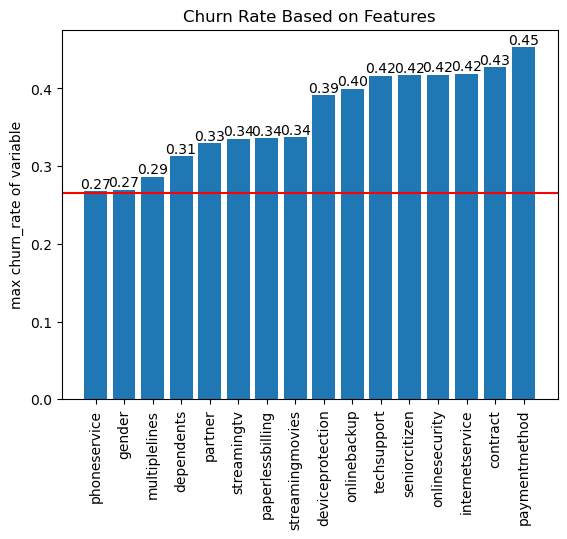

In [21]:
bars = plt.bar(categorical_var_sorted, list(sorted(churn_max_rate_list)))
plt.axhline(y = churn_rate, color= 'red')
plt.xticks(rotation = 90)
plt.bar_label(bars, fmt= '%.2f')
plt.ylabel('max churn_rate of variable')
plt.title('Churn Rate Based on Features') 
plt.show()

In [22]:
more_important_feature = categorical_var_sorted[-5:][::-1]

In [23]:
more_important_feature

['paymentmethod',
 'contract',
 'internetservice',
 'onlinesecurity',
 'seniorcitizen']

------ --Mutual Information & Entropy

In [24]:
from sklearn.metrics import mutual_info_score
from utils import *

In [25]:
mi_list = []
for cat in categorical_var_sorted:
    mi = mutual_info_score(df['churn'], df[cat])
    mi_list.append(mi)

In [28]:
entropia_list = []
for cat in categorical_var_sorted:
    entropia = conditional_entropy(df, 'churn', cat)
    entropia_list.append(entropia)

churn_entropy = entropy(df, 'churn')

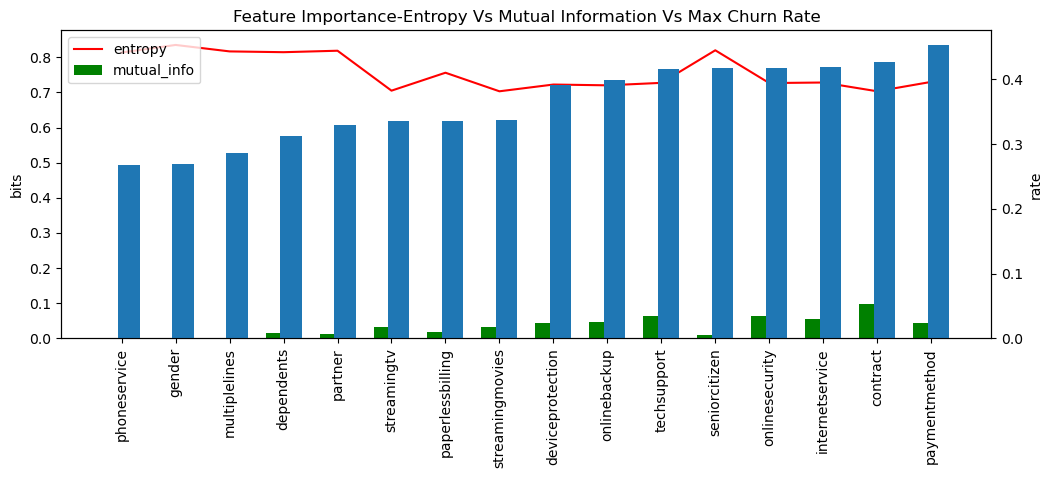

In [60]:
bar_ = np.arange(len(categorical_var_sorted))
width = 0.4
fig, ax1 = plt.subplots(figsize= (12, 4))
ax1.bar(bar_ - width / 3, mi_list, width= width, label= 'mutual_info', color= 'green')
ax1.set_ylabel('bits')
ax2 = ax1.twinx()
ax2.bar(bar_ + width / 3, list(sorted(churn_max_rate_list)), width= width, label= 'max_churn_rate')
ax2.set_ylabel('rate')
ax1.plot(categorical_var_sorted, entropia_list, color= 'red', label= 'entropy')
ax1.set_xticks(bar_, categorical_var_sorted, rotation= 90)
ax1.legend(loc= 'upper left')
plt.title('Feature Importance-Entropy Vs Mutual Information Vs Max Churn Rate')
plt.show()